In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [12]:
class BMIstate(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [7]:
def calculate_bmi(state: BMIstate) -> BMIstate:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height**2)

    state['bmi'] = round(bmi, 2)
    return state

In [13]:
def decide_category(state: BMIstate) -> BMIstate:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'
    return state

In [14]:
# define the graph
graph  = StateGraph(BMIstate)

# add node to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('decide_category', decide_category)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'decide_category')
graph.add_edge('decide_category', END)

# compile the graph
workflow = graph.compile()


In [15]:
# execute the graph

initial_state = BMIstate(weight=70, height=1.75, bmi=0)
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


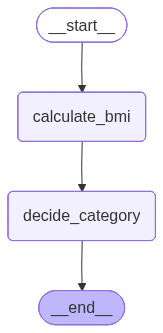

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
